# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 4. Создаем GPT-0.001 в <s>гаражных</s> общажных условиях.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 40 баллов;
* Задача 2 &mdash; 60 баллов.

In [1]:
import sys
print(sys.executable)

/Users/alexa/.pyenv/versions/3.11.6/bin/python


In [3]:
import json
import os
import re
import urllib.request
from collections import Counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from navec import Navec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid", palette="Set2")

In [4]:
import seaborn
print(seaborn.__file__)

/Users/alexa/.pyenv/versions/3.11.6/lib/python3.11/site-packages/seaborn/__init__.py


In [5]:
# Bot check

# HW_ID: fpmi_ad4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. [ссылка](https://chatgpt.com/share/69b559c4-6538-8008-aa9a-b238991c64d4)

**Задача 2**
1. ссылка
    - для чего использована


---

На лекции мы обсуждали, как работают современные языковые модели (LLM) наподобие ChatGPT: они используют архитектуру Transformer, механизм внимания (Self-Attention) и предсказывают следующий токен. Звучит как магия из мира бигтеха, правда?

Конечно, пока вы не знаете, как математически писать и обучать глубокие нейронные сети. Но знаете что? Чтобы построить **нашу собственную GPT-0.001** прямо здесь, на ваших ноутбуках в корридорах ваших общаг, вам это и не нужно! 

Фундаментальные принципы современных моделей можно понять и воспроизвести с помощью базовых инструментов, которые вы уже знаете:
* логистическая регрессия послужит нам финальным слоем предсказания,
* для представления текста в виде векторов будем использовать One-Hot преобразование,
* а понять смыслы слов на поможет старый добрый KNN!

В этом задании мы с вами шаг за шагом пройдем путь от простейшего генератора текста (символьной модели) до создания собственного механизма динамического внимания (Attention). Поехали!

---
### Задача 1.

#### 1. Данные: на чем будем учить?

Скачайте файл: [all_django.json](https://github.com/IlyaGusev/PoetryCorpus/blob/master/datasets/django/all_django.json) — это корпус стихов русских поэтов.

**Почему именно стихи?**
Обучать языковую модель с нуля на Википедии — задача для суперкомпьютеров. Наша общажная модель с таким не справится (у нас просто не хватит оперативной памяти и времени). А вот стихи — это идеальная "игрушечная вселенная" для языковой модели по нескольким причинам:
* В стихах есть рифма и ритм. Вероятность появления определенных слов или окончаний в конце строки сильно выше.
* Поэты часто используют устойчивые эпитеты («мороз и солнце», «буря мглою», «парус одинокий»). Модели будет проще выучить эти локальные зависимости.
* Лексика поэтов (особенно классиков) пересекается, что сильно упрощает задачу классификации для нашей логистической регрессии.

*Замечание.*  На самом деле не стоит думать, что стихи — это «просто». В реальности поэзия — одна из самых сложных доменных областей: омографы, где смысл и ударение зависят от контекста, инверсии, авторская пунктуация, метафоры с неочевидными семантическими связями. Полноценная генерация стихов с правильным размером и осмысленным содержанием — до сих пор не до конца решенная задача.

Давайте загрузим датасет и посмотрим на него.

In [6]:
with open("all_django.json", "r", encoding="utf-8") as f:
    all_poems = json.load(f)

data = []
for poem in all_poems:
    data.append(
        {
            "author": poem["fields"]["author"],
            "text": poem["fields"]["text"],
        }
    )

data = pd.DataFrame(data)
data["length"] = data["text"].str.len()  # количество символов
data.head()

,author,text,length
0,Михаил Лермонтов,"Забывши волнения жизни мятежной,\nОдин жил в п...",193
1,Сергей Есенин,"Нивы сжаты, рощи голы,\nОт воды туман и сырост...",291
2,Игорь Северянин,Лючинь печальная читала вечером ручьисто-вкрад...,611
3,Анатолий Жигулин,"Глыбу кварца разбили молотом,\nИ, веселым огне...",745
4,Николай Тихонов,"Хлынул дождь, когда девушки, встав в хоровод,\...",532


В данных представлено довольно много стихов

In [7]:
len(data)

16694

Посмотрим на один случайный стих

In [8]:
random_poem_index = np.random.choice(range(len(data)))
print(data.iloc[random_poem_index, 1])

Спугнув неведомую птицу,
Раздвинув заросли плечом,
Я подошел к ручью напиться
И наклонился над ручьем.
Иль ты была со мною рядом,
Иль с солнцем ты была одно:
Твоим запомнившимся взглядом
Горело искристое дно.
Или, за мною вслед приехав,
Ты близ меня была тогда!
Твоим запомнившимся смехом
Смеялась светлая вода.
И, угадав в волне нестрогой
Улыбку чистую твою,
Я не посмел губами трогать
Затрепетавшую струю.


Проведите базовый разведочный анализ данных.
* Определите топ-10 писателей по количеству стихов.
* Постройте гистограмму длины стихов (по количеству символов).
* Определите, какой стих самый длинный.

In [9]:
# количество стихов у каждого
data['author'].value_counts().head(10)

author
Владимир Высоцкий    539
Александр Пушкин     401
Александр Блок       286
Анна Ахматова        277
Афанасий Фет         251
Федор Тютчев         242
Илья Эренбург        237
Михаил Лермонтов     234
Федор Сологуб        230
Валерий Брюсов       211
Name: count, dtype: int64

In [10]:
# самый длинный стих
data.loc[data['length'].idxmax()]

author                                     Николай Некрасов
text      Посвящаю моей сестре\nАнне Алексеевне.\nТы опя...
length                                                28243
Name: 8027, dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

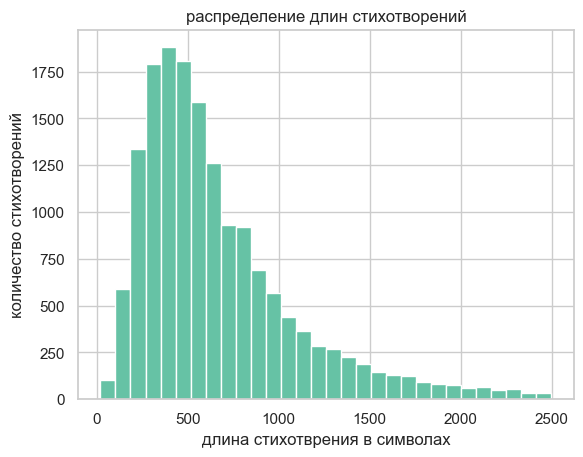

In [74]:
plt.figure()
plt.hist(data[data['length'].between(0, 2500)]['length'], bins = 30) # ограничим выборку до максимальной длины 5000, чтобы гистограмма была нагляднее
plt.title("распределение длин стихотворений")
plt.xlabel("длина стихотврения в символах")
plt.ylabel("количество стихотворений")
plt.show

Поскольку мы создаем самую простую модель (да еще и на CPU ваших компьютеров), нам нужно максимально облегчить ей жизнь. Любая пунктуация, заглавные буквы и переносы строк — это "лишний шум", на распознавание которого модели придется тратить свои силы. 

Поэтому мы проведем жесткую предобработку

In [12]:
# Переводим в нижний регистр
data["text"] = data["text"].str.lower()
# Заменяем переносы строк на пробелы
data["text"] = data["text"].str.replace("\n", " ", regex=False)
# Оставляем только буквы и пробелы
data["text"] = data["text"].str.replace(r"[^а-яё\s]", "", regex=True)
# Убираем множественные пробелы
data["text"] = data["text"].str.replace(r"\s+", " ", regex=True).str.strip()

Посмотрим, как теперь выглядит стих. Он превратился в непрерывный поток слов

In [13]:
print(data.iloc[random_poem_index, 1])

спугнув неведомую птицу раздвинув заросли плечом я подошел к ручью напиться и наклонился над ручьем иль ты была со мною рядом иль с солнцем ты была одно твоим запомнившимся взглядом горело искристое дно или за мною вслед приехав ты близ меня была тогда твоим запомнившимся смехом смеялась светлая вода и угадав в волне нестрогой улыбку чистую твою я не посмел губами трогать затрепетавшую струю


Всего количества стихов для дальнейшего анализа может оказаться много. Чтобы матрица признаков не взорвала вашу оперативную память, а модели успели обучиться до дедлайна, ограничим выборку. 

Вы можете взять больше или меньше, но не менее 1000.

*Совет:* для отладки кода (чтобы ячейки выполнялись быстро) берите `max_poems_count = 100`, а когда убедитесь, что всё работает — увеличьте это число и перезапустите ноутбук, чтобы получить более умную модель и сделать содержательные выводы.

In [83]:
max_poems_count = 1000
data_sample = data.sample(max_poems_count)

#### 2. Символьная языковая модель &mdash; простейший аналог GPT

Суть любой языковой модели (даже самой мощной) сводится к одной простой задаче — **предсказать следующий токен** на основе предыдущих. Давайте для начала в качестве "токенов" возьмем отдельные символы (буквы). Обучим нашу простую логистическую регрессию делать это предсказание!

Для формирования обучающей выборки воспользуется методом "скользящего окна". Пусть размер нашего окна (контекста) будет равен 5 символам. Мы будем двигать это окно по тексту: 5 символов идут в признаки, а 6-й символ становится нашей целевой переменной. 

> **Пример для фразы "мороз и солнце" и окна = 5:**
> * $X_1 = $ `['м', 'о', 'р', 'о', 'з']`, $Y_1 = $ `' '` (пробел)
> * $X_2 = $ `['о', 'р', 'о', 'з', ' ']`, $Y_2 = $ `'и'`
> * $X_3 = $ `['р', 'о', 'з', ' ', 'и']`, $Y_3 = $ `' '` (пробел)
> * и так далее...


*Замечание.* По сути мы сейчас строим классическую $N$-граммную модель — одну из старейших идей в области обработки естественного языка. В нашем случае – это 6-граммная на уровне символов. Можно было бы обойтись и без логистической регрессии: просто посчитать, как часто после комбинации `['о', 'р', 'о', 'з', ' ']` встречается каждый символ, и превратить частоты в оценку вероятности. Это и есть статистическая n-граммная модель. Однако, используя логистическую регрессию, наша модель сможет обобщаться на комбинации символов, которых она ни разу не видела в обучающей выборке.

Сформируйте массивы `X_raw` &mdash; списки из 5 символов и `y_raw` &mdash; следующий символ.

In [84]:
window_size = 5  # Количество символов в истории

X_raw = []
y_raw = []

# Перебираем случайные max_poems_count стихов
for text in tqdm(data_sample["text"]):

    # Проверка на случай, если после очистки текст стал короче окна
    if len(text) <= window_size:
        continue

    window = list(text[:window_size])

    for i in range(window_size, len(text) - 1):
        X_raw.append(window.copy())
        y_raw.append(text[i])

        window.pop(0)
        window.append(text[i])


  0%|          | 0/1000 [00:00<?, ?it/s]

Посмотрим, сколько всего получилось комбинаций и как выглядят несколько первых

In [85]:
print(f"Размер выборки: {len(X_raw)}")
for x, y in zip(X_raw[:20], y_raw[:20]):
    print(x, y)

Размер выборки: 704168
['ч', 'а', 'с', 'о', 'в'] а
['а', 'с', 'о', 'в', 'а'] я
['с', 'о', 'в', 'а', 'я']  
['о', 'в', 'а', 'я', ' '] с
['в', 'а', 'я', ' ', 'с'] т
['а', 'я', ' ', 'с', 'т'] р
['я', ' ', 'с', 'т', 'р'] е
[' ', 'с', 'т', 'р', 'е'] л
['с', 'т', 'р', 'е', 'л'] к
['т', 'р', 'е', 'л', 'к'] а
['р', 'е', 'л', 'к', 'а']  
['е', 'л', 'к', 'а', ' '] б
['л', 'к', 'а', ' ', 'б'] л
['к', 'а', ' ', 'б', 'л'] и
['а', ' ', 'б', 'л', 'и'] з
[' ', 'б', 'л', 'и', 'з'] и
['б', 'л', 'и', 'з', 'и'] т
['л', 'и', 'з', 'и', 'т'] с
['и', 'з', 'и', 'т', 'с'] я
['з', 'и', 'т', 'с', 'я']  


Соберем словарь всех уникальных символов, которые встретились в `y_raw`. Эти символы станут **классами**, которые будет предсказывать наша логистическая регрессия.

In [86]:
chars = sorted(list(set(y_raw)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}
n_chars = len(chars)

print(f"Всего уникальных символов: {n_chars}")

Всего уникальных символов: 34


Преобразуйте `X_raw` в числовую матрицу признаков с помощью знакомого вам **One-Hot Encoding**. 

In [87]:
encoder  = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(X_raw)

y = np.array([char_to_idx[c] for c in y_raw])

Сколько всего получилось признаков? Почему их столько много?

всего 5 букв у каждой буквы 34 состояний  иотого $\approx$ 34 * 5

In [88]:
X.shape

(704168, 170)

Отлично! У нас есть матрица признаков $X$ и вектор ответов $y$. 

Обучите логистическую регрессию. Поскольку данных и классов много, возможно, потребуется увеличить количество итераций обучения модели. Также может помочь замена на `SGDClassifier` с параметром `loss='log_loss'`, это та же логистическая регрессия.

In [89]:
model = LogisticRegression(max_iter = 1000000)
model.fit(X, y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [90]:
model.score(X, y) # тоность

0.286359221094966

Бинго! Наша нейросеть, состоящая ровно из одного линейного слоя, обучена. Да да, нейросеть!

При генерации текста в современных LLM часто используют параметр **температуры**. Он управляет "креативностью" модели. Если всегда выбирать строго символ с максимальной вероятностью, модель будет зацикливаться и выдавать скучный, повторяющийся текст. Температура позволяет нам сэмплировать следующий символ, хитро меняя распределение вероятностей.

> **Принцип работы:**
> 
> Наша регрессия выдает "сырые" уверенности модели — логиты ($\ell_k$). Чтобы получить оценки вероятностей $P_k$, в многоклассовой логистической регрессии мы применяем функцию Softmax:
> 
> $$P_k = \frac{\exp\left({\ell_k}\right)}{\sum_{j} \exp\left({\ell_j}\right)}$$
> 
> Температура $T$ просто делит логиты перед экспонентой:
> 
> $$P'_k = \frac{\exp\left({\left.\ell_k \right/ T}\right)}{\sum_{j}\exp\left({\left.\ell_j \right/ T}\right)}$$
> На основе этого мы получаем новое распределение вероятностей, из которого будет производиться сэмплирование. 

Опираясь на эту формулу, поясните своими словами, как будет вести себя модель (насколько случайным будет выбор) при следующих значениях $T$:
* $T \approx 0$ Почти вся вероятность переходит к символу с максимальным логитом. Модель почти всегда выбирает один и тот же самый вероятный символ, то есть генерация становится  менее разнообразной.


* $0 < T < 1$ Наиболее вероятные символы выбираются ещё чаще, а маловероятные ещё реже. Текст обычно получается более связным и предсказуемым, но менее разнообразным


* $T = 1$ это исходное распределение без изменений. Модель сэмплирует символы ровно по тем вероятностям, которые выдала сама.


* $T > 1$ распределение становится более “плоским” разница между вероятностями уменьшается поэтому текст становится более случайным и разнообразным, но может стать менее связным и более шумным.

Пришло время заставить нашу модель говорить! Напишите функцию генерации текста. 

Вам нужно:
1. Взять последние 5 символов текста.
2. Преобразовать их через one hot энкодер.
3. Получить предсказания вероятностей из логистической регрессии.
4. Применить температуру к полученным вероятностям (по формуле выше).
5. Сделать случайный выбор символа с помощью `np.random.choice`.

In [91]:
def generate_text(model: Any, start_text: str, length: int = 60, temperature: float = 1.0) -> str:
    """Генерирует текст посимвольно на основе обученной модели.
    :param model: Обученная модель классификации (например, SGDClassifier).
    :param start_text: Начальная строка, с которой начнется генерация.
    :param length: Количество символов для генерации.
    :param temperature: Температура сэмплирования (управляет случайностью выбора).
    :return: Сгенерированная строка текста."""
    current_text = start_text.lower()

    for _ in range(length):
        context = list(current_text[-window_size:])
        # Если контекст меньше окна, дополним пробелами
        while len(context) < window_size:
            context.insert(0, " ")

        # Получите предсказание вероятностей
        X_context = encoder.transform([context])
        probabilities = model.predict_proba(X_context)[0]

        logits = np.log(probabilities + 1e-12)
        # Примените температуру
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probabilities = exp_logits / exp_logits.sum()
        

        # Сгенерируйте следующий символ и добавьте его к тексту.
        # Используйте np.random.choice(..., p=probabilities) и idx_to_char
        next_idx = np.random.choice(np.arange(len(probabilities)), p=probabilities)
        next_char = idx_to_char[next_idx]
        current_text += next_char

    return current_text

Давайте потестируем нашего Франкенштейна! Запустим генерацию с разными стартовыми фразами и разными значениями температуры.

In [92]:
temperature_list = [0.1, 0.8, 1.5]
text_list = [
    "мороз и сол",
    "буря мгл",
]

for text in text_list:
    for temperature in temperature_list:
        generated_text = generate_text(model, text, temperature=temperature)
        print(f"Температура {temperature}: {generated_text}")

Температура 0.1: мороз и солоно моло на провот постоли на стора стора ста не сторой поро
Температура 0.8: мороз и солобем а пренив ерсееше на моноцо вемлушил а сься от браз васн
Температура 1.5: мороз и сол цы дудый нучтнотдяж лкик серндыйтое цаничаноей авдцое велье
Температура 0.1: буря мгля на стора стора сторой полода но постол на сторой воров сто
Температура 0.8: буря мглы и зоркий моста тамы трусти у стоенны свком ини онихи скав 
Температура 1.5: буря мглеб с ещера нобовилью мисятя чую тскваюннадыпокия дый знслепы


Посмотрите на сгенерированные тексты. Похоже ли это на русский язык? Появляются ли осмысленные слова? Как влияет температура на результат?

Не сильно похоже, осмысленных слов почти нет, при увелечении температуры реже поялвялются пробелы, слова длиннее. При меньшей температре чаще повторяются слова

#### 3. Заглядываем внутрь модели

Модель как-то научилась собирать буквы в слоги, похожие на русские. Но как она принимает решения? На какую из 5 позиций в нашем контекстном "окне" она смотрит больше всего? 

Для начала вспомните, что означают коэффициенты модели, если все признаки находятся в одном масштабе (у нас все признаки бинарные)?

...

Посмотрим на количество коэффициентов модели

In [93]:
model.coef_.shape

(34, 170)

Давайте визуализируем важности для конкретного предсказываемого символа (например, для буквы "я").

In [94]:
target_char = "я"

# Извлеките коэффициенты для target_char и приведите к нужному размеру

target_idx = char_to_idx[target_char]
influence = model.coef_[target_idx].reshape(window_size, n_chars)
assert influence.shape == (window_size, n_chars)
pd.DataFrame(influence)

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,-0.481321,0.081272,0.264272,0.002512,0.223038,0.154542,0.071663,-0.011768,0.048501,0.008183,...,0.416645,-0.109936,0.246942,-0.114378,0.093273,0.103756,-0.322498,0.056008,0.148333,0.033880
1,-0.329299,-0.003708,0.073675,0.158466,0.672348,-0.007622,-0.079699,0.265536,0.150581,-0.024325,...,0.232639,0.304319,0.367103,1.182068,-0.194458,0.174131,0.239302,-0.056884,0.120504,-0.018067
2,-0.720365,0.171096,-0.736473,-0.256743,0.403885,-0.033234,0.194271,-0.336624,0.131083,0.334692,...,-0.363238,0.125028,-0.018213,-0.348672,0.084279,0.390169,-0.082047,0.550570,0.354375,-0.012021
3,-2.895768,-1.090930,0.522621,0.218005,1.664308,0.870776,-0.547726,0.225160,-0.185512,-0.825733,...,0.303157,0.358462,1.372235,-0.048341,-0.404004,0.575339,-0.572260,0.016963,-0.672083,-0.058611
4,-0.120799,0.291004,2.260137,1.004057,-1.648838,1.071475,-2.140010,-1.442437,1.428204,-0.723037,...,-1.546950,-1.628217,-0.714011,4.619057,-2.962972,1.868761,-0.179408,-1.954045,-0.689066,-0.289447


Нарисуем тепловую карту, где красный цвет означает положительный вес, синий — отрицательный.

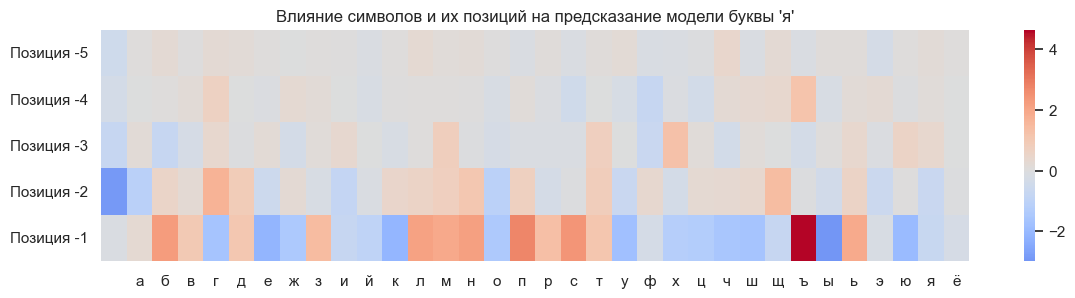

In [95]:
plt.figure(figsize=(14, 3))
sns.heatmap(
    influence,
    xticklabels=chars,
    yticklabels=[f"Позиция -{window_size-i}" for i in range(window_size)],
    cmap="coolwarm",
    center=0,
)
plt.title(f"Влияние символов и их позиций на предсказание модели буквы '{target_char}'")
plt.show()

Посмотрите также аналогичные графики для нескольких других символов.

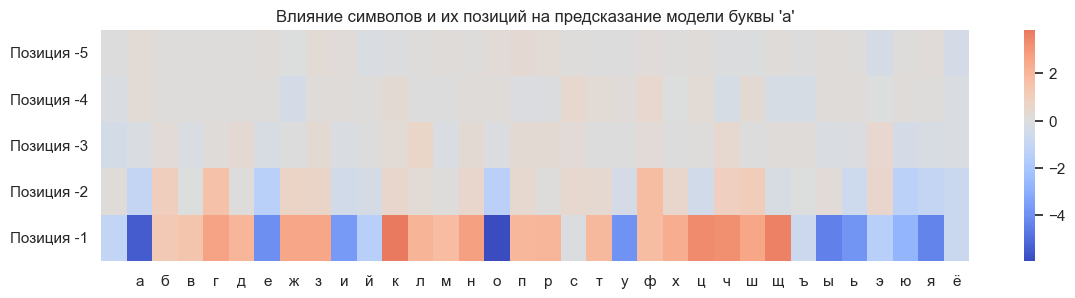

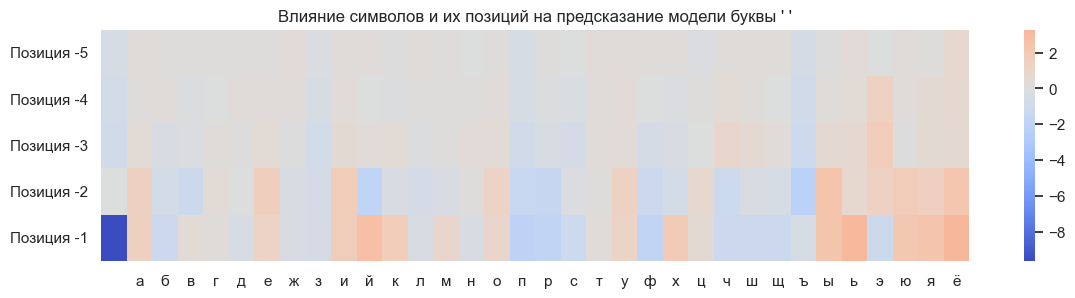

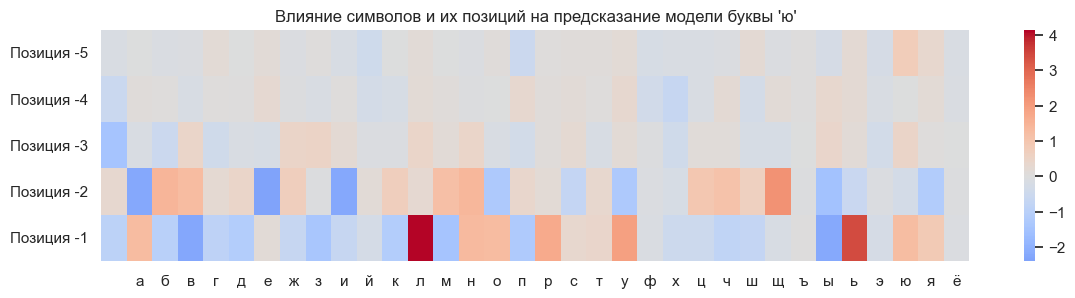

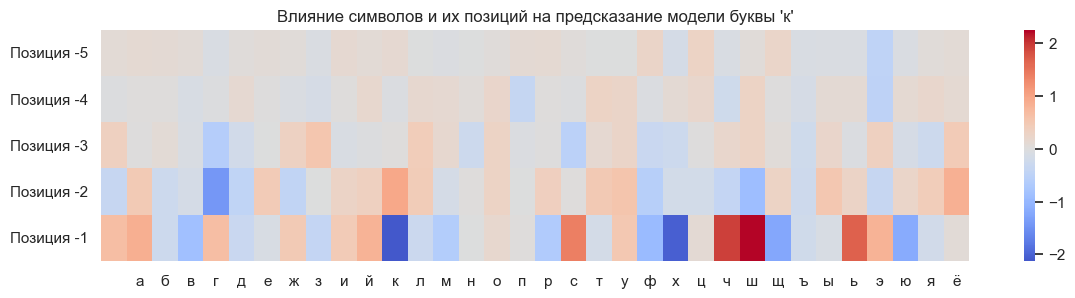

In [96]:
target_chars = ["а", " ", "ю", "к"]
for target_char in target_chars:

    target_idx = char_to_idx[target_char]
    influence = model.coef_[target_idx].reshape(window_size, n_chars)
    assert influence.shape == (window_size, n_chars)

    plt.figure(figsize=(14, 3))
    sns.heatmap(
        influence,
        xticklabels=chars,
        yticklabels=[f"Позиция -{window_size-i}" for i in range(window_size)],
        cmap="coolwarm",
        center=0,
    )
    plt.title(f"Влияние символов и их позиций на предсказание модели буквы '{target_char}'")
    plt.show()

Можно ли увидеть какие-то закономерности? Какие позиции влияют сильнее всего?

1) После гласными самые большое влияние оказывает -1 позиция
2) Если окно кончается на режкую букву типа: ь, ш, (твердый знак) и тд, они оказывают большрое влияние.
3) после пробела никогда не может идити пробел
4) очень редко бываю 2 согласных подряд
5) для гласных последняя классная плияют отрицательно, посоледняя согласная положительно
6) самый нижний ряд как правило самый яркий, следоваптельно именно -1 позиция влияюет больше всего

Постройте "карту общей важности позиций". Для каждой из 5 позиций в окне посчитайте суммарный абсолютный вес (по модулю) по всем символам и всем классам, отобразите их в виде bar plot.

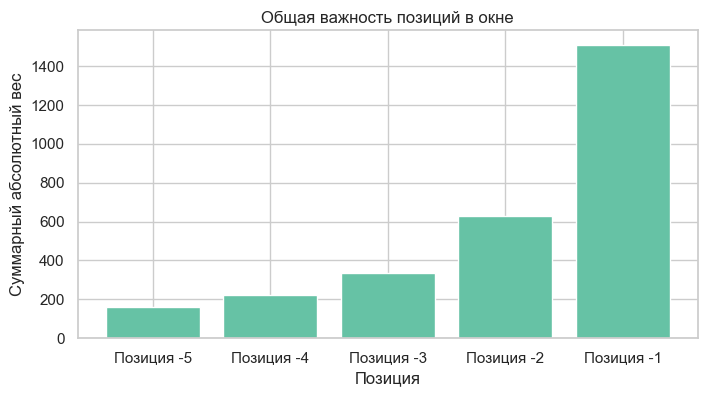

In [97]:
coef_3d = model.coef_.reshape(len(model.classes_), window_size, n_chars)

# для каждой позиции суммируем абсолютные веса по всем классам и всем символам
position_importance = np.abs(coef_3d).sum(axis=(0, 2))

positions = [f"Позиция -{window_size - i}" for i in range(window_size)]

plt.figure(figsize=(8, 4))
plt.bar(positions, position_importance)
plt.title("Общая важность позиций в окне")
plt.ylabel("Суммарный абсолютный вес")
plt.xlabel("Позиция")
plt.show()

**Выводы:**

На графике видно, что сильнее всего влияет позиция -1, то есть последний символ в окне. Позиция -2 тоже важна, но заметно слабее. Чем дальше символ от конца окна, тем меньше его вклад.

Значит, модель в основном опирается на ближайший контекст. Это логично: следующий символ чаще всего определяется последними 1–2 буквами, а более дальние позиции играют вспомогательную роль.

---
### Задача 2.

#### 1. От one-hot к смыслам: эмбеддинги слов

Мы переходим от предсказания букв к предсказанию целых слов!

Загрузим предобученную модель эмбеддингов **Navec** от проекта Natasha. Эти векторы были обучены на огромном корпусе текстов. В процессе обучения перебирались различные тексты и векторы слов, которые часто встречаются рядом, передвигались ближе друг к другу в многомерном пространстве.

Мы будем использовать версию `hudlit`, которая обучалась на русской художественной литературе.

Каждое слово в Navec — это вектор из 300 чисел.

In [98]:
navec_url = (
    "https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar"
)
navec_path = "navec_hudlit_v1_12B_500K_300d_100q.tar"
if not os.path.exists(navec_path):
    urllib.request.urlretrieve(navec_url, navec_path)

Загрузим модель и убедимся, что вектор слова `солнце` действительно содержит 300 чисел:

In [99]:
navec = Navec.load(navec_path)
navec["солнце"].shape

(300,)

Напишите функцию, которая принимает вектор целевого слова и возвращает $K$ самых близких к нему слов из заданного списка `vocab`. 

Меру близости мы будем оценивать через косинусное расстояние (по сути, это скалярное произведение нормированных векторов). Чем ближе косинус угла между векторами к 1, тем больше похож их смысл.

In [100]:
vocab = [
    "любовь", "сердце", "душа", "мечта", "судьба", "небо",
    "звезда", "ветер", "туман", "море", "ночь", "луна", "солнце",
    "закат", "рассвет", "тоска", "печаль", "радость", "счастье",
    "жизнь", "береза", "поле", "дорога", "тьма", "мгла",
]


def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Вычисляет косинусное сходство между двумя числовыми векторами.
    :param v1: Первый вектор (numpy массив).
    :param v2: Второй вектор (numpy массив).
    :return: Значение косинусного сходства (от -1.0 до 1.0)."""

    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

In [101]:
def find_nearest_in_vocab(word: str, vocab: list[str], k: int = 3) -> list[tuple[str, float]]:
    """Находит k ближайших слов к заданному слову из словаря на основе косинусного сходства.
    :param word: Целевое слово для поиска ближайших по смыслу слов.
    :param vocab: Список слов (словарь), среди которых ведется поиск.
    :param k: Количество возвращаемых ближайших соседей.
    :return: Список кортежей вида (слово, косинусное сходство), отсортированный по убыванию."""

    target_vec = navec[word]
    result = []

    for other_word in vocab:
        if other_word == word:
            continue
        sim = cosine_similarity(target_vec, navec[other_word])
        result.append((other_word, sim))

    result.sort(key=lambda x: x[1], reverse=True)
    return result[:k]

Давайте проверим, как наша модель понимает смыслы

In [102]:
test_words = ["сердце", "солнце", "тьма"]

for word in test_words:
    print(f"Ближайшие к слову {word}:")
    print(find_nearest_in_vocab(word, vocab))

Ближайшие к слову сердце:
[('душа', np.float32(0.49851114)), ('любовь', np.float32(0.4197443)), ('тоска', np.float32(0.37497467))]
Ближайшие к слову солнце:
[('луна', np.float32(0.61312574)), ('небо', np.float32(0.6014561)), ('закат', np.float32(0.48348323))]
Ближайшие к слову тьма:
[('мгла', np.float32(0.7252577)), ('туман', np.float32(0.5133756)), ('луна', np.float32(0.46272776))]


#### 2. Механизм Внимания (Self-Attention)

Как объяснить модели, на какое слово в контексте смотреть прямо сейчас? На самом деле Attention — это в некотором смысле "мягкий KNN"

Вместо того чтобы жестко выбирать $K$ соседей, назначая им вес 1, а остальным 0, мы берем все слова в контексте, но каждому выдаем свой "вес важности" (от 0 до 1).

> **Принцип работы**
> 
> Пусть у нас есть текущее слово-запрос $q$ и остальные слова $v_j, j\in C$ в контексте $C$ (окно). В нашей общажной модели всё это — векторы-эмбеддинги из Navec.
> 
> 1. С помощью скалярного произведения оцениваем, насколько запрос $q$ близок по смыслу к каждому слову $v_j$ в окне:
>    $$s_j = q^T  v_j$$
>    
>     *Смысл: чем ближе векторы по направлению (по смыслу), тем больше будет это число.*
> 
> 
> 2. Чтобы превратить "сырые" числа в проценты (в сумме дающие 1.0), прогоняем их через Softmax с температурой $T$, получая тем самым веса Attention:
>    $$\alpha_j = \frac{ \exp\left({\left.s_j \right/ T}\right)}{\sum_{j} \exp\left({\left.s_j \right/ T}\right)}$$
> 
> 
> 3. Итоговый вектор контекста $C$ — это взвешенная сумма векторов всех слов в этом контексте:
>    $$u_c = \sum_{j} \alpha_j v_j$$
> 
>     *Итог: получается новый вектор $u_c$, впитавший смыслы всего контекста пропорционально их важности!*


Реализуйте функцию Softmax с параметром температуры.

*Совет*: для вычислительной стабильности перед применением экспоненты вычтите из массива максимальное значение `x := x - max(x)`. Это спасет от переполнения при возведении $e$ в огромную степень, а результат после нормировки останется математически идентичным.

In [ ]:
def softmax(x: np.ndarray | list[float], temperature: float = 1.0) -> np.ndarray:
    """Вычисляет функцию Softmax с применением температуры для массива значений.
    :param x: Массив сырых значений (логитов).
    :param temperature: Температура сглаживания распределения (по умолчанию 1.0).
    :return: Массив вероятностей, сумма которых равна 1.0."""
    ...

Допустим, у нас есть фраза: *"они сошлись волна и камень стихи и проза лед и пламень"*. Как слова обращают внимание друг на друга? 

Принцип Self-Attention в самом базовом виде работает следующим образом. 
Мы берем векторы всех слов и считаем скалярное произведение каждого слова с каждым. Это наша матрица "сырой похожести". В формулах Трансформера это шаг $Q K^T$ (где Query и Key — это одни и те же слова нашего предложения). Затем применяем функцию Softmax к каждой строке этой матрицы. Она превращает сырые числа в веса внимания (от 0.0 до 1.0).

*Замечание.* На самом деле $Q,K$ – это разные линейные проекции одних и тех же входных векторов слов. То есть слова в предложении одни и те же, но каждое из них представлено двумя разными векторами: "что я ищу" (вектор query) и "что я могу предложить" (key).

Давайте посчитаем это и нарисуем!



In [ ]:
sentence = "они сошлись волна и камень стихи и проза лед и пламень"
words = sentence.split()

# Получаем векторы слов
vecs = np.array([...])

# Матрица попарных скалярных произведений
# Это показывает, насколько "похожи" векторы слов друг на друга
scores = ...

# Применяем Softmax
attention_matrix = np.apply_along_axis(softmax, 1, scores)

plt.figure(figsize=(10, 4))
sns.heatmap(
    attention_matrix,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    vmax=0.2,
    cmap="Blues",
    cbar=False,
)
plt.title("Self-Attention в стихах (кто с кем связан)")
plt.yticks(rotation=0)
plt.show()

Кажется, мы увидели не то, что ожидали. Мы видим единичную матрицу (с точностью до повторяющихся слов). Наша модель стала эгоисткой — каждое слово смотрит на 99.9% только на само себя, игнорируя весь остальной контекст....

Все дело в проклятии размерности. Эмбеддинги имеют длину 300 чисел. Когда мы умножаем вектор сам на себя скалярно ($v_1^T v_1$), число получается огромным (например, 20 или 30). А скалярное произведение с другим, даже близким по смыслу словом ($v_1^T v_2$), получается сильно меньше (например, 2 или 5). 

Когда эти числа попадают в экспоненту внутри Softmax, разница становится огромной: $e^{30}$ против $e^5$. Функция Softmax делает из самого большого числа абсолютную единицу `1.0`, а всё остальное просто зануляет.

Именно поэтому авторы статьи "Attention is All You Need" придумали **Scaled Dot-Product Attention** &mdash; деление всех значений на корень из размерности вектора перед применением Softmax. Размерность у нас 300, получаем $\sqrt{300} \approx 17.3$.

В нашей функции `softmax` уже есть параметр `temperature`, который делает ровно это. Добавьте `temperature=20.0`, чтобы сгладить распределение и заставить слова смотреть по сторонам!

In [ ]:
...

Посмотрите на новый график. Какие слова (кроме самих себя) оказались сильно связаны между собой по смыслу в понимании модели?

...

#### 3. Собираем всё вместе: языковая модель на основе Attention

Сам по себе механизм Attention не умеет предсказывать следующее слово. Он лишь создает идеальное математическое представление контекста — вектор контекста.  Это просто взвешенная сумма векторов слов контекста, где весами выступают те самые вероятности из матрицы Attention. 
Получив этот супер-информативный вектор, мы передадим его в нашу обычную логистическую регрессию для классификации (предсказания следующего слова). Примерно так работают слои `Linear + Softmax` в конце архитектуры GPT!

Для начала, ограничим наш словарь. Предсказывать все уникальные слова из стихов для логистической регрессии будет сложно, поскольку классов будут десятки тысяч. Оставим только те слова, которые встречаются хотя бы 10 раз. Редкие слова предсказывать не будем.

In [ ]:
min_count = 10  # Задаем порог: слово должно встретиться минимум N раз
window_size = 4  # количество предыдущих слов, на основе которых будем предсказывать следующее

In [ ]:
# Собираем все слова в один список
all_words = []
for text in data_sample["text"]:
    all_words.extend(text.split())

# Считаем, сколько раз встречается каждое слово
counts = Counter(all_words)

# Оставляем только частые слова для предсказания
vocab_words = [word for word, count in counts.items() if count >= min_count]

# Создаем  word_to_idx только для частых слов
# Это будет наш список классов для классификации
word_to_idx = {word: i for i, word in enumerate(vocab_words)}

print(f"Всего слов в текстах: {len(counts)}")
print(f"Осталось слов после фильтрации (размер словаря): {len(word_to_idx)}")

Теперь соберем наш датасет для регрессии следующим образом.
1. Идем по тексту "окном" из 4 слов. Целевая метка $Y$ — 5-е слово.
2. Берем эмбеддинги этих 4 слов из Navec.
3. Слово, которое стоит прямо перед пропуском, будет нашим "запросом" (query). Мы хотим понять: *с учетом этого последнего слова, на что еще в контексте нужно обратить внимание?*
4. Считаем скалярные произведения query со всеми словами в окне.
5. Применяем Softmax с температурой 20, получая тем самым веса Attention.
6. Умножаем матрицу векторов на эти веса — получаем единый кектор контекста. Это и будут наши признаки $X$.

In [ ]:
X_attn = []
y_words = []

for text_string in tqdm(data_sample["text"]):
    words = text_string.split()

    if len(words) <= window_size:
        continue

    for i in range(len(words) - window_size):
        context = words[i : i + window_size]
        target = words[i + window_size]

        # Целевое слово должно быть популярным (быть в нашем новом словаре)
        if target not in word_to_idx:
            # Пропускаем, не будем учить модель предсказывать редкое слово
            continue

        # Слова контекста должны быть известны Navec (чтобы взять векторы)
        try:
            vecs = np.array([navec[w] for w in context])
        except KeyError:
            # Если хоть одно слово неизвестно Navec - пропускаем
            continue

        # Посчитайте вектор Attention
        query = vecs[-1]
        scores = vecs @ query
        context_vector = ...

        X_attn.append(context_vector)
        y_words.append(word_to_idx[target])

X_attn = np.array(X_attn)
y_words = np.array(y_words)

print(f"Итоговая размерность X: {X_attn.shape}")
print(f"Итоговая размерность y: {y_words.shape}")

Матрица признаков имеет размер `(n, 300)`, то есть мы сжали 4 слова в один вектор размером 300 чисел. Но благодаря Attention, в отличие от простого усреднения, этот вектор динамически подчеркнул самые важные по смыслу слова.

Теперь обучим логистическую регрессию предсказывать индекс следующего слова по этому вектору контекста.

In [ ]:
...

Финальный штрих. Напишем функцию генерации текста, которая будет использовать нашу обученную Attention-модель.

Процесс генерации на каждом шаге выглядит следующим образом.
1. Берем последние 4 слова текста и достаем их эмбеддинги.
2. Вычисляем вектор контекста.
3. Передаем его в логистическую регрессию для предсказания вероятностей.
4. Применяем температуру сэмплирования к вероятностям и выбираем следующее слово.

Допишите недостающие части кода в функции.

In [ ]:
def generate_with_attention(
    seed_words: list[str], length: int = 10, temperature: float = 1.0
) -> str:
    """Генерирует текст по словам, используя механизм Attention и логистическую регрессию.
    :param seed_words: Список начальных слов для старта генерации.
    :param length: Количество слов для генерации.
    :param temperature: Температура для генерации.
    :return: Итоговая сгенерированная строка текста."""

    current_words = seed_words.copy()

    # Создадим обратный словарь
    idx_to_word = {i: w for w, i in word_to_idx.items()}

    for _ in range(length):
        # Контекст
        context = current_words[-window_size:]

        # Если слово незнакомо, берем нулевой вектор
        vecs = np.array([navec[w] if w in navec else np.zeros(300) for w in context])

        # Механизм Внимания (как раньше)
        query = vecs[-1]
        scores = vecs @ query
        context_vector = ...  # здесь temperature=20, это не температура генерации!

        # Выполните оценку вероятностей, примените температуру и сгенерируйте следующее слово
        next_word_idx = ...

        next_word = idx_to_word[next_word_idx]
        current_words.append(next_word)

    return " ".join(current_words)

Барабанная дробь! Запускаем нашу GPT-0.001.

In [ ]:
# Параметры генерации
length = 20
temperatures = [0.5, 1.0, 2.0]

examples = ["буря мглою небо кроет", "белеет парус одинокий в тумане моря"]


for i, text in enumerate(examples, 1):
    seed_words = text.split()
    for temp in temperatures:
        result = generate_with_attention(seed_words, length=length, temperature=temp)
        print(f"T={temp}: {result}")

Оцените результат:
* Насколько осмысленными получаются генерации по сравнению с посимвольной моделью из первой части?
* Удается ли модели сохранять тему заданных стартовых слов?
* Что можно было бы улучшить в нашей "общажной" модели, если бы у нас было больше вычислительных мощностей?

...

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД